In [1]:
import pandas as pd

In [4]:
data = pd.read_csv('OnlineRetail.csv',encoding='ISO-8859-1')

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [6]:
data.dropna(subset=['CustomerID'],inplace=True)
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])


In [8]:
data=data[(data['Quantity']>0) & (data['UnitPrice']>0)]

In [9]:
data['TotalPrice']=data['Quantity']*data['UnitPrice']

In [12]:
import datetime
snapshot_date= data['InvoiceDate'].max() + datetime.timedelta(days=1)
rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, 
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [13]:
print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


In [14]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [15]:
import numpy as np
rfm_log = np.log(rfm + 1)


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

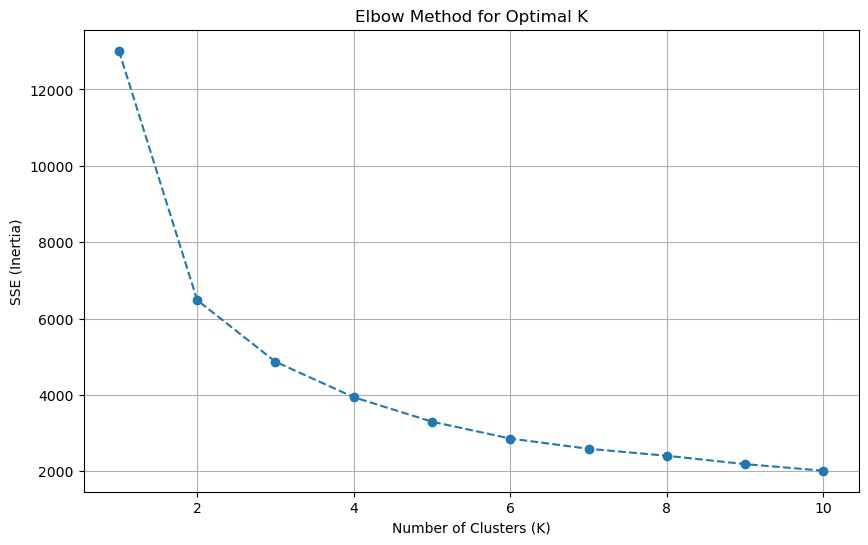

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
sse=[]
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    sse.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE (Inertia)')
plt.grid(True)
plt.show()

In [22]:
final_kmeans = KMeans(n_clusters=2, random_state=42)
rfm['Cluster'] = final_kmeans.fit_predict(rfm_scaled)
cluster_analysis = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).sort_values('Monetary', ascending=False)
print(cluster_analysis)

            Recency  Frequency     Monetary
Cluster                                    
1         25.700241   8.468637  4566.961870
0        133.885075   1.675746   499.770568


In [23]:
import plotly.express as px
fig = px.scatter_3d(rfm, 
                    x='Recency', 
                    y='Frequency', 
                    z='Monetary',
                    color='Cluster',
                    title='3D Visualization of Customer Segments',
                    log_x=True, log_y=True, log_z=True, # 使用对数轴能让分布更均匀
                    opacity=0.6)

fig.show()

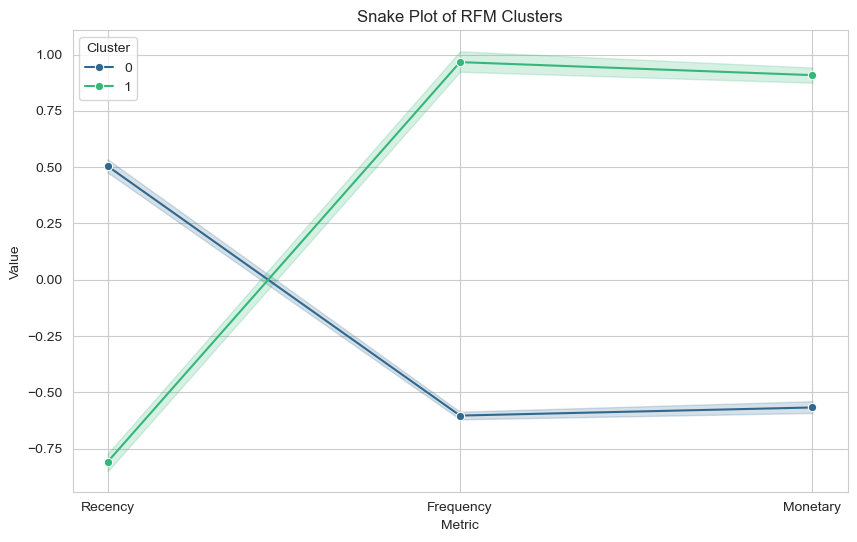

In [25]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(rfm_scaled)

rfm['Cluster'] = kmeans.labels_

rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df['Cluster'] = kmeans.labels_ 

rfm_melted = pd.melt(rfm_scaled_df.reset_index(), 
                      id_vars=['CustomerID', 'Cluster'],
                      value_vars=['Recency', 'Frequency', 'Monetary'],
                      var_name='Metric', 
                      value_name='Value')

plt.figure(figsize=(10, 6))
sns.lineplot(x='Metric', y='Value', hue='Cluster', data=rfm_melted, palette='viridis', marker='o')
plt.title('Snake Plot of RFM Clusters')
plt.show()

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 1. 准备数据
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Cluster']

# 2. 划分训练集和测试集 (80% 训练, 20% 测试)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 创建随机森林
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# 4. 评估结果
y_pred = rf.predict(X_test)

print("--- 随机森林分类报告 ---")
print(classification_report(y_test, y_pred))

--- 随机森林分类报告 ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       532
           1       0.99      0.97      0.98       336

    accuracy                           0.99       868
   macro avg       0.99      0.98      0.98       868
weighted avg       0.99      0.99      0.99       868



/var/folders/6k/4s_z6c8s5dx_9h2wcyq523dh0000gn/T/ipykernel_4999/2010441830.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


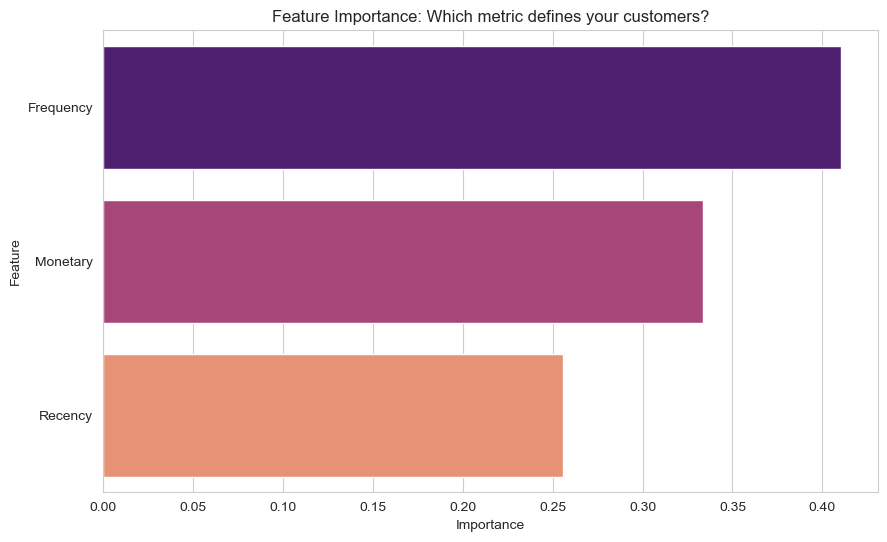

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 获取特征重要性
importances = rf.feature_importances_
feature_names = ['Recency', 'Frequency', 'Monetary']

# 2. 整理成 DataFrame
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. 绘图
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Feature Importance: Which metric defines your customers?')
plt.show()

In [30]:
import joblib

# 1. 保存标准化工具 (必须保存，因为新数据也需要同样的 Scale 逻辑)
joblib.dump(scaler, 'scaler.pkl')

# 2. 保存随机森林分类模型
joblib.dump(rf, 'rf_model.pkl')

# 3. 保存 KMeans 模型 (可选，如果你想保留聚类能力)
joblib.dump(kmeans, 'kmeans_model.pkl')

print("✅ 模型与预处理工具已成功固化！")

✅ 模型与预处理工具已成功固化！
